In [101]:
import numpy as np
import pandas as pd
from collections import Counter 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
pd.set_option('display.max_columns',None)

In [102]:
data = pd.read_csv('https://raw.githubusercontent.com/lovvmg/Breast-Cancer-Wisconsin-Diagnostic-/refs/heads/main/data.csv')
data.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [103]:
x = data.drop(columns=['id','diagnosis','Unnamed: 32']).values
y = data['diagnosis'].values

x_train, x_test , y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=2)
### disini berarti yang jadi newpoint itu si x_test, pointsnya adalah si x_train dan y_train

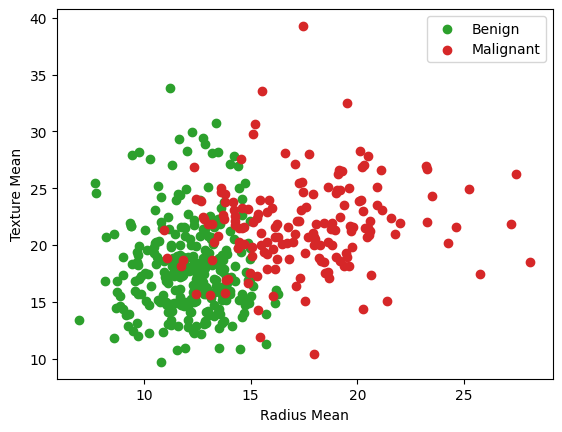

In [104]:
#plt.scatter(sumbu_x, sumbu_y, ...)
#visualisasi 2D
plt.scatter(x_train[y_train == 'B',0],x_train[y_train == 'B',1], color='tab:green', label='Benign')
plt.scatter(x_train[y_train == 'M',0],x_train[y_train == 'M',1], color='tab:red', label='Malignant')
plt.xlabel('Radius Mean')
plt.ylabel('Texture Mean')
plt.legend()
plt.show()

In [105]:
# scaler = StandardScaler()
# x_train = scaler.fit_transform(x_train)
# x_test = scaler.transform(x_test)

In [106]:
def euclidean_distance(a,b):
    return np.sqrt(np.sum((b-a)**2))

In [107]:
class KNN:

    def __init__(self,k):
        self.k=k

    def fit(self,x_train,y_train):
        self.x_train = x_train
        self.y_train = y_train

    def predict(self, x_test):
        predictions = [self.predict_class(newpoint) for newpoint in x_test]
        return np.array(predictions)

    def predict_class(self, newpoint):
        distances = [euclidean_distance(point,newpoint) for point in self.x_train]

        k_nearest_indices = np.argsort(distances)[:self.k]
        k_nearest_labels = [self.y_train[i] for i in k_nearest_indices]

        most_common = Counter(k_nearest_labels).most_common(1)[0][0]
        return most_common

       

        
            

In [108]:
from sklearn.model_selection import cross_val_score

for k in [1, 3, 5, 7, 9, 11]:
    knn = KNN(k)
    scores = []
    # cross_val_score butuh sklearn estimator API,
    # kalau KNN ini custom class, manual k-fold lebih gampang:

from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=2)
for k in [1, 3, 5, 7, 9, 11]:
    fold_acc = []
    for train_idx, val_idx in kf.split(x):
        x_train, x_test = x[train_idx], x[val_idx]
        y_train, y_test = y[train_idx], y[val_idx]
        
        # scaler = StandardScaler()
        # x_tr_scaled = scaler.fit_transform(x_tr)
        # x_val_scaled = scaler.transform(x_val)
        scaler = StandardScaler()
        x_train = scaler.fit_transform(x_train)
        x_test = scaler.transform(x_test)
        
        knn = KNN(k)
        knn.fit(x_train,y_train)
        preds = knn.predict(x_test)
        fold_acc.append(np.mean(preds == y_test))
    
    print(f"k={k}: {np.mean(fold_acc)*100:.2f}% (+/- {np.std(fold_acc)*100:.2f}%)")


k=1: 95.08% (+/- 1.05%)
k=3: 97.18% (+/- 1.52%)
k=5: 96.66% (+/- 1.30%)
k=7: 96.48% (+/- 0.98%)
k=9: 96.65% (+/- 1.90%)
k=11: 96.65% (+/- 1.90%)
